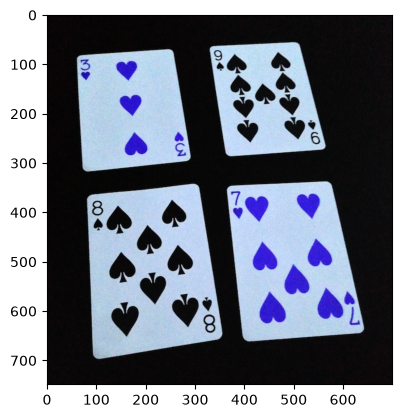

In [34]:
import cv2 as cv
import matplotlib.pyplot as plt
image1 = cv.imread('cards.png')
if image1 is None:
    raise FileNotFoundError("Không tìm thấy file image.png.")
plt.imshow(image1)
plt.show()

In [35]:
image1.shape

(749, 700, 3)

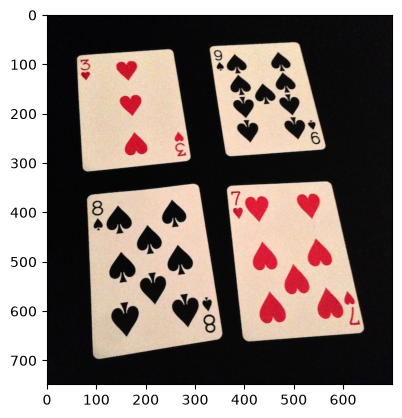

In [36]:
image1_RGB = cv.cvtColor(image1, cv.COLOR_BGR2RGB)
plt.imshow(image1_RGB)

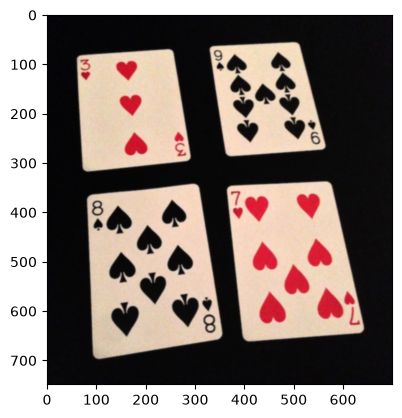

In [37]:
image1_blur = cv.GaussianBlur(image1_RGB, (5, 5), 0)
plt.imshow(image1_blur)

In [38]:
image1_blur.shape

(749, 700, 3)

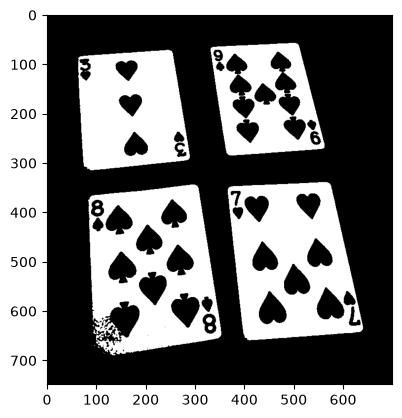

In [39]:
image1_gray = cv.cvtColor(image1_blur, cv.COLOR_RGB2GRAY)
image1_threshold = cv.threshold(image1_gray, 200, 255, cv.THRESH_BINARY)[1]
plt.imshow(image1_threshold, cmap='gray')

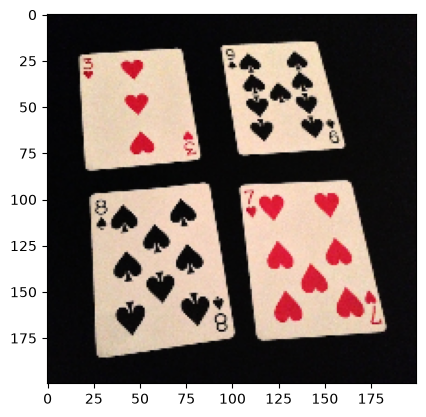

In [40]:
image1_resize = cv.resize(image1_RGB, (200, 200))
plt.imshow(image1_resize)

In [41]:
image1_resize[: , 48:52, :] = 0

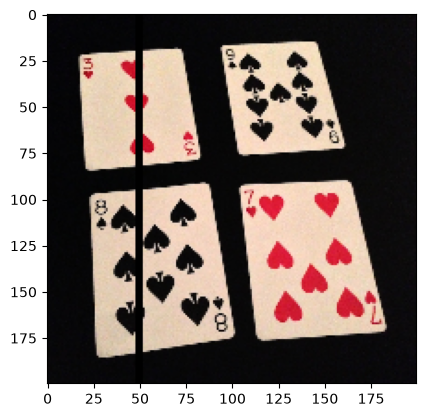

In [42]:
plt.imshow(image1_resize)

In [43]:
image1_cut = image1_resize[:, 20:60, :]

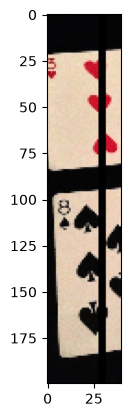

In [44]:
plt.imshow(image1_cut)

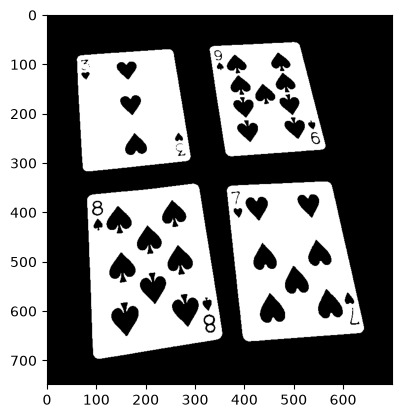

In [45]:
image1_gray = cv.cvtColor(image1_blur, cv.COLOR_RGB2GRAY)
ret, image1 = cv.threshold(image1_gray, 125, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
plt.imshow(image1, cmap='gray')

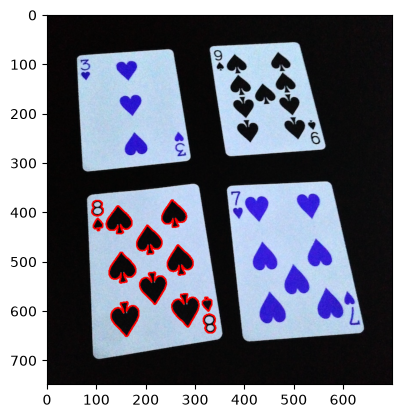

In [51]:
image1_BGR = cv.imread('cards.png')
img_copy = image1_BGR.copy()
contours, hierarchy = cv.findContours(image1, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)
#Find contours in the image (mono only)
for i in range(len(contours)):
    if hierarchy[0][i][3] == 4:
        cv.drawContours(img_copy, contours, i, (255, 0, 0), 2)
plt.imshow(img_copy)

In [47]:
hierarchy

array([[[ 1, -1, -1, -1],
        [ 2,  0, -1, -1],
        [ 3,  1, -1, -1],
        [ 4,  2, -1, -1],
        [17,  3,  5, -1],
        [ 6, -1, -1,  4],
        [ 7,  5, -1,  4],
        [ 8,  6, -1,  4],
        [ 9,  7, -1,  4],
        [10,  8, -1,  4],
        [11,  9, -1,  4],
        [12, 10, -1,  4],
        [13, 11, -1,  4],
        [14, 12, -1,  4],
        [15, 13, -1,  4],
        [16, 14, -1,  4],
        [-1, 15, -1,  4],
        [30,  4, 18, -1],
        [19, -1, -1, 17],
        [20, 18, -1, 17],
        [21, 19, -1, 17],
        [22, 20, -1, 17],
        [23, 21, -1, 17],
        [24, 22, -1, 17],
        [25, 23, -1, 17],
        [26, 24, -1, 17],
        [27, 25, -1, 17],
        [28, 26, -1, 17],
        [29, 27, -1, 17],
        [-1, 28, -1, 17],
        [31, 17, -1, -1],
        [32, 30, -1, -1],
        [53, 31, 33, -1],
        [34, -1, -1, 32],
        [35, 33, -1, 32],
        [36, 34, -1, 32],
        [37, 35, -1, 32],
        [38, 36, -1, 32],
        [39,

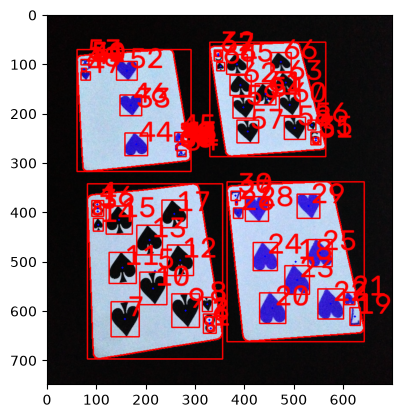

In [48]:
center_points = []
i=0

for cnt in contours:
    i+=1

    x, y, w, h = cv.boundingRect(cnt)
    cv.rectangle(img_copy, (x, y), (x + w, y + h), (255, 0, 0), 2)
    center_x = x + w // 2
    center_y = y + h // 2
    cv.circle(img_copy, (center_x, center_y), 2, (0, 0, 255), -1)
    cv.putText(img_copy, str(i), (center_x + 5, center_y - 5), cv.FONT_HERSHEY_SIMPLEX,2, (255, 0, 0), 1)
    center_points.append((center_x, center_y))
plt.imshow(img_copy)

In [49]:
center_points[0][0] - center_points[0][1] 

-303